In [1]:

#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("="*50)
print("Libraries Imported Successfully")
print("="*50)


# Upload Dataset


#from google.colab import files

#uploaded = files.upload()


df = pd.read_csv("customer_churn.csv")

print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

Libraries Imported Successfully

First 5 Rows
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QJUXO    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No     Fiber optic             No  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport St

In [2]:


# Data Cleaning & Preprocessing

# Remove customerID column if present
if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values
for column in df.columns:

    if df[column].dtype == "object":
        df[column] = df[column].fillna(df[column].mode()[0])

    else:
        df[column] = df[column].fillna(df[column].median())

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

# Encode categorical columns
label_encoders = {}

for column in df.columns:

    if df[column].dtype == "object":

        encoder = LabelEncoder()

        df[column] = encoder.fit_transform(df[column])

        label_encoders[column] = encoder

print("\nCategorical Features Encoded Successfully!")

# Save encoders
with open("label_encoders.pkl", "wb") as file:
    pickle.dump(label_encoders, file)

# Split Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("\nFeature Shape :", X.shape)
print("Target Shape :", y.shape)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

print("\nPreprocessing Completed Successfully!")


Missing Values After Cleaning
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Categorical Features Encoded Successfully!

Feature Shape : (5, 19)
Target Shape : (5,)

Training Data Shape : (3, 19)
Testing Data Shape : (2, 19)

Preprocessing Completed Successfully!


Training Logistic Regression...
Logistic Regression Accuracy: 1.0000

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


Confusion Matrix
[[1 0]
 [0 1]]

Training Random Forest...
Random Forest Accuracy: 1.0000

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


Confusion Matrix
[[1 0]
 [0 1]]

Model Comparison
Logistic Regression Accuracy : 1.0000
Random Forest Accuracy       : 1.0000

Best Model :

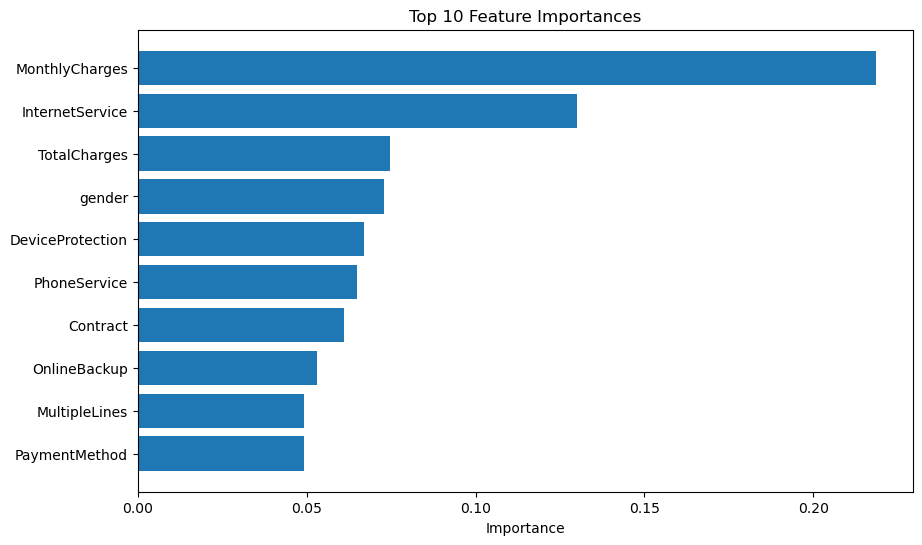

In [3]:


# Model Training & Evaluation


# Logistic Regression Model
print("=" * 50)
print("Training Logistic Regression...")
print("=" * 50)

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_predictions = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, log_predictions)

print(f"Logistic Regression Accuracy: {log_accuracy:.4f}")

print("\nClassification Report")
print(classification_report(y_test, log_predictions))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, log_predictions))



# Random Forest Model

print("\n" + "=" * 50)
print("Training Random Forest...")
print("=" * 50)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

print("\nClassification Report")
print(classification_report(y_test, rf_predictions))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_predictions))



# Compare Models


print("\n" + "=" * 50)
print("Model Comparison")
print("=" * 50)

print(f"Logistic Regression Accuracy : {log_accuracy:.4f}")
print(f"Random Forest Accuracy       : {rf_accuracy:.4f}")

if rf_accuracy >= log_accuracy:
    best_model = rf_model
    print("\nBest Model : Random Forest")
else:
    best_model = log_model
    print("\nBest Model : Logistic Regression")



# Save Best Model


with open("churn_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("\nBest model saved as churn_model.pkl")


# Feature Importance (Random Forest)


if isinstance(best_model, RandomForestClassifier):

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("\nTop 10 Important Features")
    print(importance.head(10))

    plt.figure(figsize=(10,6))
    plt.barh(
        importance["Feature"].head(10),
        importance["Importance"].head(10)
    )
    plt.title("Top 10 Feature Importances")
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.show()

In [4]:


# Prediction & Model Testing


# Load saved model
with open("churn_model.pkl", "rb") as file:
    model = pickle.load(file)

print("=" * 50)
print("Model Loaded Successfully!")
print("=" * 50)

# Predict on test dataset
predictions = model.predict(X_test)

print("\nFirst 10 Predictions")
print(predictions[:10])

print("\nActual Values")
print(y_test.values[:10])

# ROC-AUC Score
try:
    probability = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, probability)

    print(f"\nROC-AUC Score : {auc:.4f}")

except:
    print("ROC-AUC Score not available.")


# Predict New Customer


print("\nPredicting for a New Customer...")

sample_customer = X.iloc[[0]]

prediction = model.predict(sample_customer)

if prediction[0] == 1:
    print("\nPrediction : Customer is likely to Churn.")
else:
    print("\nPrediction : Customer is likely to Stay.")

# Save Prediction Results


results = X_test.copy()
results["Actual"] = y_test
results["Predicted"] = predictions

results.to_csv("prediction_results.csv", index=False)

print("\nPrediction results saved as prediction_results.csv")


# Model Summary


print("\n" + "=" * 50)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 50)

print("✔ Dataset Loaded")
print("✔ Data Cleaned")
print("✔ Missing Values Handled")
print("✔ Features Encoded")
print("✔ Models Trained")
print("✔ Best Model Selected")
print("✔ Predictions Generated")
print("✔ Model Saved (churn_model.pkl)")
print("✔ Prediction Results Saved (prediction_results.csv)")
print("=" * 50)

Model Loaded Successfully!

First 10 Predictions
[0 1]

Actual Values
[0 1]

ROC-AUC Score : 1.0000

Predicting for a New Customer...

Prediction : Customer is likely to Stay.

Prediction results saved as prediction_results.csv

PROJECT COMPLETED SUCCESSFULLY
✔ Dataset Loaded
✔ Data Cleaned
✔ Missing Values Handled
✔ Features Encoded
✔ Models Trained
✔ Best Model Selected
✔ Predictions Generated
✔ Model Saved (churn_model.pkl)
✔ Prediction Results Saved (prediction_results.csv)
